## Libraries

In [1]:
import os
import warnings 
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression     
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, auc

import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [2]:
import shap

## Data import

- from Kaggle (https://www.kaggle.com/datasets/kartik2112/fraud-detection)

- train, test로 나뉜 데이터로 test 데이터에 정답이 함께 있어 이것으로 성능 측정

In [3]:
train = pd.read_csv('dataset/fraud_train.csv')
test = pd.read_csv('dataset/fraud_test.csv')

train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
test.head(1)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0


인덱스였던 column `'Unnamed: 0'`은 의미가 없으므로 drop

In [5]:
train.drop(columns=['Unnamed: 0'], inplace=True)
test.drop(columns=['Unnamed: 0'], inplace=True)


## EDA

### <div style="color:rgb(4, 108, 211);"> **1. summary: types and missing values** </div>


In [6]:
print(train.shape, test.shape)

(1296675, 22) (555719, 22)


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop          

In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  555719 non-null  object 
 1   cc_num                 555719 non-null  int64  
 2   merchant               555719 non-null  object 
 3   category               555719 non-null  object 
 4   amt                    555719 non-null  float64
 5   first                  555719 non-null  object 
 6   last                   555719 non-null  object 
 7   gender                 555719 non-null  object 
 8   street                 555719 non-null  object 
 9   city                   555719 non-null  object 
 10  state                  555719 non-null  object 
 11  zip                    555719 non-null  int64  
 12  lat                    555719 non-null  float64
 13  long                   555719 non-null  float64
 14  city_pop               555719 non-nu

In [9]:
# 정답 데이터가 두 가지로 잘 나뉘어 있는지 확인
print(train['is_fraud'].unique().sort()==test['is_fraud'].unique().sort())

True


### missung value 찾기

- merch_zip이 원래 결측치가 많아 이 데이터셋에서 미리 지운 것으로 확인됨

<Axes: >

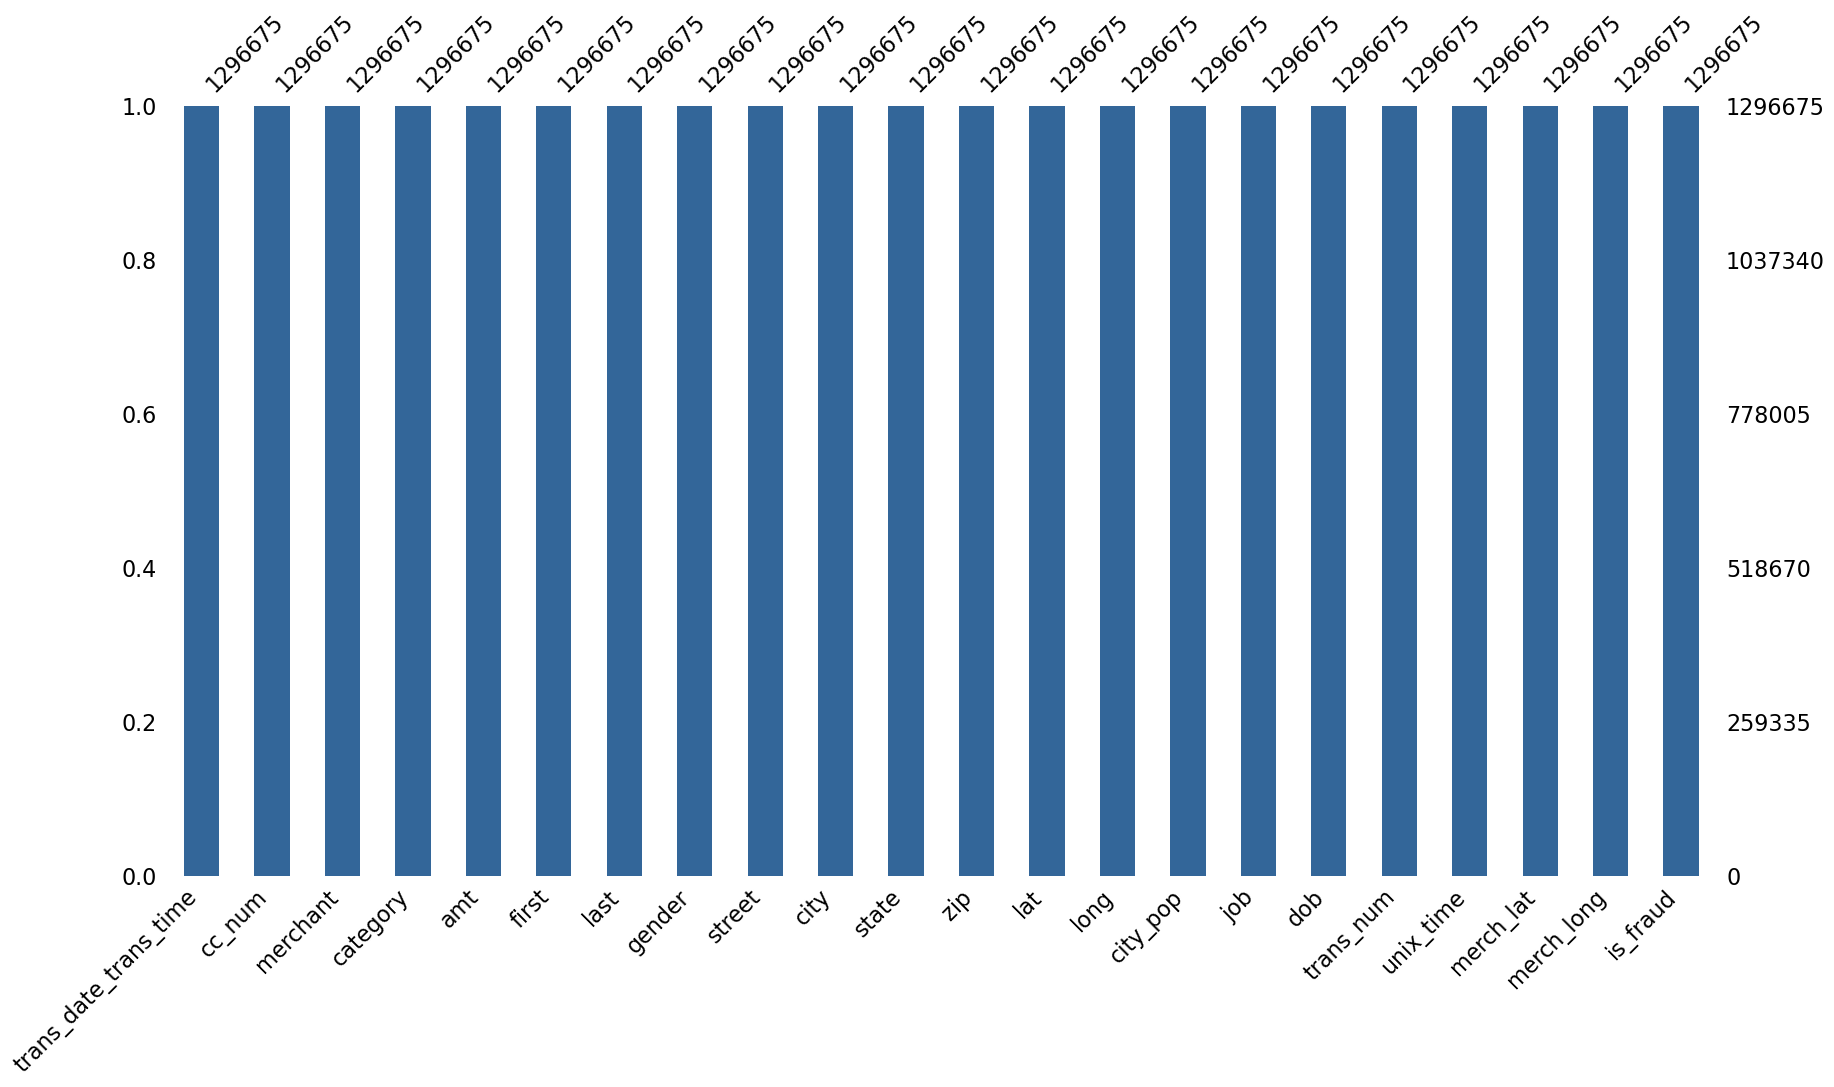

In [10]:
import missingno as msno

msno.bar(df = train, figsize=(20, 10), color=(0.2, 0.4, 0.6))

* 원래 데이터에는 zipcode에만 결측치가 존재하는 것을 확인, 데이터레코드 순서와는 무관하게 소실된 상태인 것도 확인
* 현 데이터는 수정되어 신경쓸 필요 없음

### <div style="color:rgb(4, 108, 211);"> **2. meaning: columns and values range** </div>


* trans_date_trans_time - Transaction datetime
* cc_num - Credit card number
* merchant - Merchant(Company) name
* category - Merchant category
* amt - Transaction amount

* first - Customer's first name
* last - Customer's last name
* gender - Customer's gender
* street - Customer's street address
* city - Customer's city
* state - Customer's state
* zip - Customer's ZIP code of transaction place
* lat - Customer's latitudee of transaction place
* long - Customer's longitudee of transaction place
* city_pop - City population
* job - Customer's occupation
* dob - Customer's date of birth

* trans_num - Transaction ID
* unix_time - Transaction time in Unix time stamp
* merch_lat - Merchant's latitude
* merch_long - Merchant's longitude
* is_fraud - Fraud indicator (0 or 1)
* ~~merch_zipcode - Merchant's ZIP code~~

🤫 So we have to think about...  

    - cc_num은 의미없는 숫자형으로 거래유저 id 취급
    - merchant는 거래가 일어난 업소명으로 추정
    - 위치와 관련된 정보는 거래회원의 회원 정보이고, 이어 나오는 merch_lat/long이 거래업소의 위치로 추측됨
    - trans_num이 데이터의 unique_id


In [11]:
pd.options.display.float_format = '{:,.2f}'.format
train.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,"1,296,675.00","1,296,675.00","1,296,675.00","1,296,675.00","1,296,675.00","1,296,675.00","1,296,675.00","1,296,675.00","1,296,675.00","1,296,675.00"
mean,"417,192,042,079,726,656.00",70.35,"48,800.67",38.54,-90.23,"88,824.44","1,349,243,636.73",38.54,-90.23,0.01
std,"1,308,806,447,000,789,248.00",160.32,"26,893.22",5.08,13.76,"301,956.36","12,841,278.42",5.11,13.77,0.08
min,"60,416,207,185.00",1.00,"1,257.00",20.03,-165.67,23.00,"1,325,376,018.00",19.03,-166.67,0.00
25%,"180,042,946,491,150.00",9.65,"26,237.00",34.62,-96.80,743.00,"1,338,750,742.50",34.73,-96.90,0.00
50%,"3,521,417,320,836,166.00",47.52,"48,174.00",39.35,-87.48,"2,456.00","1,349,249,747.00",39.37,-87.44,0.00
75%,"4,642,255,475,285,942.00",83.14,"72,042.00",41.94,-80.16,"20,328.00","1,359,385,375.50",41.96,-80.24,0.00
max,"4,992,346,398,065,154,048.00","28,948.90","99,783.00",66.69,-67.95,"2,906,700.00","1,371,816,817.00",67.51,-66.95,1.00


In [12]:
test.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,"555,719.00","555,719.00","555,719.00","555,719.00","555,719.00","555,719.00","555,719.00","555,719.00","555,719.00","555,719.00"
mean,"417,838,695,528,764,096.00",69.39,"48,842.63",38.54,-90.23,"88,221.89","1,380,678,865.17",38.54,-90.23,0.00
std,"1,309,836,622,980,698,624.00",156.75,"26,855.28",5.06,13.72,"300,390.89","5,201,104.07",5.10,13.73,0.06
min,"60,416,207,185.00",1.00,"1,257.00",20.03,-165.67,23.00,"1,371,816,865.00",19.03,-166.67,0.00
25%,"180,042,946,491,150.00",9.63,"26,292.00",34.67,-96.80,741.00,"1,376,028,627.50",34.76,-96.91,0.00
50%,"3,521,417,320,836,166.00",47.29,"48,174.00",39.37,-87.48,"2,408.00","1,380,761,988.00",39.38,-87.45,0.00
75%,"4,635,330,563,105,903.00",83.01,"72,011.00",41.89,-80.18,"19,685.00","1,385,866,984.00",41.95,-80.26,0.00
max,"4,992,346,398,065,154,048.00","22,768.11","99,921.00",65.69,-67.95,"2,906,700.00","1,388,534,374.00",66.68,-66.95,1.00


In [13]:
train.describe(include='object')

,trans_date_trans_time,merchant,category,first,last,gender,street,city,state,job,dob,trans_num
count,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675
unique,1274791,693,14,352,481,2,983,894,51,494,968,1296675
top,2019-04-22 16:02:01,fraud_Kilback LLC,gas_transport,Christopher,Smith,F,0069 Robin Brooks Apt. 695,Birmingham,TX,Film/video editor,1977-03-23,0b242abb623afc578575680df30655b9
freq,4,4403,131659,26669,28794,709863,3123,5617,94876,9779,5636,1


In [14]:
test.describe(include='object')

,trans_date_trans_time,merchant,category,first,last,gender,street,city,state,job,dob,trans_num
count,555719,555719,555719,555719,555719,555719,555719,555719,555719,555719,555719,555719
unique,544760,693,14,341,471,2,924,849,50,478,910,555719
top,2020-12-19 16:02:22,fraud_Kilback LLC,gas_transport,Christopher,Smith,F,444 Robert Mews,Birmingham,TX,Film/video editor,1977-03-23,2da90c7d74bd46a0caf3777415b3ebd3
freq,4,1859,56370,11443,12146,304886,1474,2423,40393,4119,2408,1


📌 
- object type의 unique가 거의 비슷한 것으로 보임
    - 그래도 완전히 같지는 않으니, train+test 데이터 단계에서 전처리가 필요해 보임
- 숫자 type의 값들 범위는 크게 차이나보이진 않음

### <div style="color:rgb(4, 108, 211);"> **3. meaning: columns and values range and unique values** </div>

dtype 수정 후 피처 요약표로 정리

In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop          

In [16]:
train.head(2)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.08,-81.18,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.01,-82.05,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.89,-118.21,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.16,-118.19,0


In [17]:
datetime_cols = ['trans_date_trans_time', 'dob', 'unix_time']
for col in datetime_cols:
    train[col] = pd.to_datetime(train[col])
    test[col] = pd.to_datetime(test[col])

binary_cols = ['is_fraud']

In [18]:
# 요약표 함수
def resumetable(df):
    print(f'데이터 세트 형상: {df.shape}')
    summary = pd.DataFrame(df.dtypes, columns=['데이터 타입'])
    summary['결측값 개수'] = df.isna().sum()
    summary['고윳값 개수'] = df.nunique().values
    summary['데이터 종류'] = None
    for col in df.columns:
        if col in datetime_cols:
            summary.loc[col, '데이터 종류'] = '이진형'
        elif df[col].dtype == object:
            summary.loc[col, '데이터 종류'] = '명목형'
        elif df[col].dtype == float:
            summary.loc[col, '데이터 종류'] = '연속형'
        elif df[col].dtype == int:
            summary.loc[col, '데이터 종류'] = '순서형'
        elif col in binary_cols:
            summary.loc[col, '데이터 종류'] = '이진형'

    return summary

In [19]:
pd.concat([resumetable(train), resumetable(test)], axis=1, keys=['train', 'test'])

데이터 세트 형상: (1296675, 22)
데이터 세트 형상: (555719, 22)


train                                   test  \
                               데이터 타입 결측값 개수   고윳값 개수 데이터 종류          데이터 타입   
trans_date_trans_time  datetime64[ns]      0  1274791    이진형  datetime64[ns]   
cc_num                          int64      0      983   None           int64   
merchant                       object      0      693    명목형          object   
category                       object      0       14    명목형          object   
amt                           float64      0    52928    연속형         float64   
first                          object      0      352    명목형          object   
last                           object      0      481    명목형          object   
gender                         object      0        2    명목형          object   
street                         object      0      983    명목형          object   
city                           object      0      894    명목형          object   
state                          object      0       51    명목형          object   
zip                             int64      0      970   None           int64   
lat                           float64      0      968    연속형         float64   
long                          float64      0      969    연속형         float64   
city_pop                        int64      0      879   None           int64   
job                            object      0      494    명목형          object   
dob                    datetime64[ns]      0      968    이진형  datetime64[ns]   
trans_num                      object      0  1296675    명목형          object   
unix_time              datetime64[ns]      0  1274823    이진형  datetime64[ns]   
merch_lat                     float64      0  1247805    연속형         float64   
merch_long                    float64      0  1275745    연속형         float64   
is_fraud                        int64      0        2    이진형           int64   

                                             
                      결측값 개수  고윳값 개수 데이터 종류  
trans_date_trans_time      0  544760    이진형  
cc_num                     0     924   None  
merchant                   0     693    명목형  
category                   0      14    명목형  
amt                        0   37256    연속형  
first                      0     341    명목형  
last                       0     471    명목형  
gender                     0       2    명목형  
street                     0     924    명목형  
city                       0     849    명목형  
state                      0      50    명목형  
zip                        0     912   None  
lat                        0     910    연속형  
long                       0     910    연속형  
city_pop                   0     835   None  
job                        0     478    명목형  
dob                        0     910    이진형  
trans_num                  0  555719    명목형  
unix_time                  0  544760    이진형  
merch_lat                  0  546490    연속형  
merch_long                 0  551770    연속형  
is_fraud                   0       2    이진형

int가 안읽히는 사소한 문제는 넘어가자 어차피 순서형도 아님

📌 
- `zip`, `cc_num`은 카테고리로 의미가 있으며, `city_pop`은 순서형으로서의 의미가 없음

### <div style="color:rgb(4, 108, 211);"> **4. visualization with target value** </div>


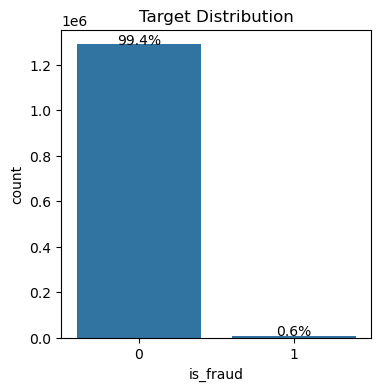

In [20]:
def write_percent(ax, total_size):
    '''도형 객체를 순회하며 막대 그래프 상단에 타깃값 비율 표시'''
    for patch in ax.patches:
        height = patch.get_height()     # 도형 높이(데이터 개수)
        width = patch.get_width()       # 도형 너비
        left_coord = patch.get_x()      # 도형 왼쪽 테두리의 x축 위치
        percent = height/total_size*100 # 타깃값 비율
        
        # (x, y) 좌표에 텍스트 입력
        ax.text(left_coord + width/2.0,     # x축 위치
                height + total_size*0.001,  # y축 위치
                '{:1.1f}%'.format(percent), # 입력 텍스트
                ha='center')                # 가운데 정렬
    
mpl.rc('font', size=10)
plt.figure(figsize=(4, 4))

ax = sns.countplot(x='is_fraud', data=train)
write_percent(ax, len(train)) # 비율 표시
ax.set_title('Target Distribution');
plt.show()

📌 
- target value가 심각한 불균형을 띄고 있기 때문에~! 소수인 1을 잘 예측하도록 만들어야 함
    - 각 피처의 고윳값 별로 target `1`의 비율을 알아보도록 하자.

#### category 형 피처 with target values

In [21]:
import matplotlib.gridspec as gridspec

target = 'is_fraud'

def plot_target_ratio_by_features(df, features, num_rows, num_cols, 
                                  size=(12, 18)):
    mpl.rc('font', size=9) 
    plt.figure(figsize=size)                     # 전체 Figure 크기 설정
    grid = gridspec.GridSpec(num_rows, num_cols) # 서브플롯 배치
    plt.subplots_adjust(wspace=0.3, hspace=0.3)  # 서브플롯 좌우/상하 여백 설정

    for idx, feature in enumerate(features):
        ax = plt.subplot(grid[idx])
        # ax축에 고윳값별 타깃값 1 비율을 막대 그래프로 그리기
        sns.barplot(x=feature, y=target, data=df, palette='Set2', ax=ax)
    
    plt.show()

In [22]:
summary = resumetable(train)

nom_features = summary[summary['데이터 종류'] == '명목형'].index # 사실상 object type
nom_features

데이터 세트 형상: (1296675, 22)


Index(['merchant', 'category', 'first', 'last', 'gender', 'street', 'city',
       'state', 'job', 'trans_num'],
      dtype='object')

In [23]:
for f in nom_features:
    if train[f].nunique() > 20:
        pass
    else:
        print(f, train[f].nunique(), train[f].unique()) 
    

category 14 ['misc_net' 'grocery_pos' 'entertainment' 'gas_transport' 'misc_pos'
 'grocery_net' 'shopping_net' 'shopping_pos' 'food_dining' 'personal_care'
 'health_fitness' 'travel' 'kids_pets' 'home']
gender 2 ['F' 'M']


문제는 현 데이터 셋에서 고유값이 20개가 넘지 않는 컬럼은 둘 뿐, 이들만이라도 시각화. 

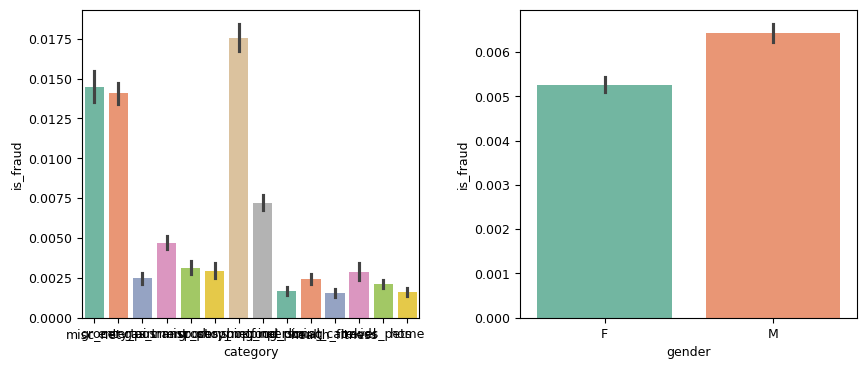

In [24]:
plot_target_ratio_by_features(train, ['category', 'gender'], 1, 2, size = (10, 4)) # 1X2 그리드

📌
- category는 category에 따라서 1의 비율이 다르므로 사용 가능
- gender도 약간의 차이라도 보이고 있기 때문에 일단 사용해보는 것으로 결정

#### 지리 관련 피처 with target values

- state나 city 관련해서도 알아보는 것이 좋을 것 같다는 생각을 하였음
    - `train['state'].nunique()` 는 51임
- 

In [25]:
import pandas as pd
import geopandas
from shapely.geometry import Point
import matplotlib.pyplot as plt

In [26]:
geo_train_cumstomer = [Point(xy) for xy in zip(train['long'], train['lat'])]
geo_df_us = geopandas.GeoDataFrame(train, geometry=geo_train_cumstomer, crs="EPSG:4326")

In [27]:
# 미국 주 경계 shapefile 불러오기 (shx 파일과 함께 있어야 함)
try:
    us_states = geopandas.read_file("dataset/US_states.shp")
except FileNotFoundError:
    print("미국 주 경계 shapefile을 찾을 수 없습니다. 배경 지도 없이 점만 표시합니다.")
    us_states = None

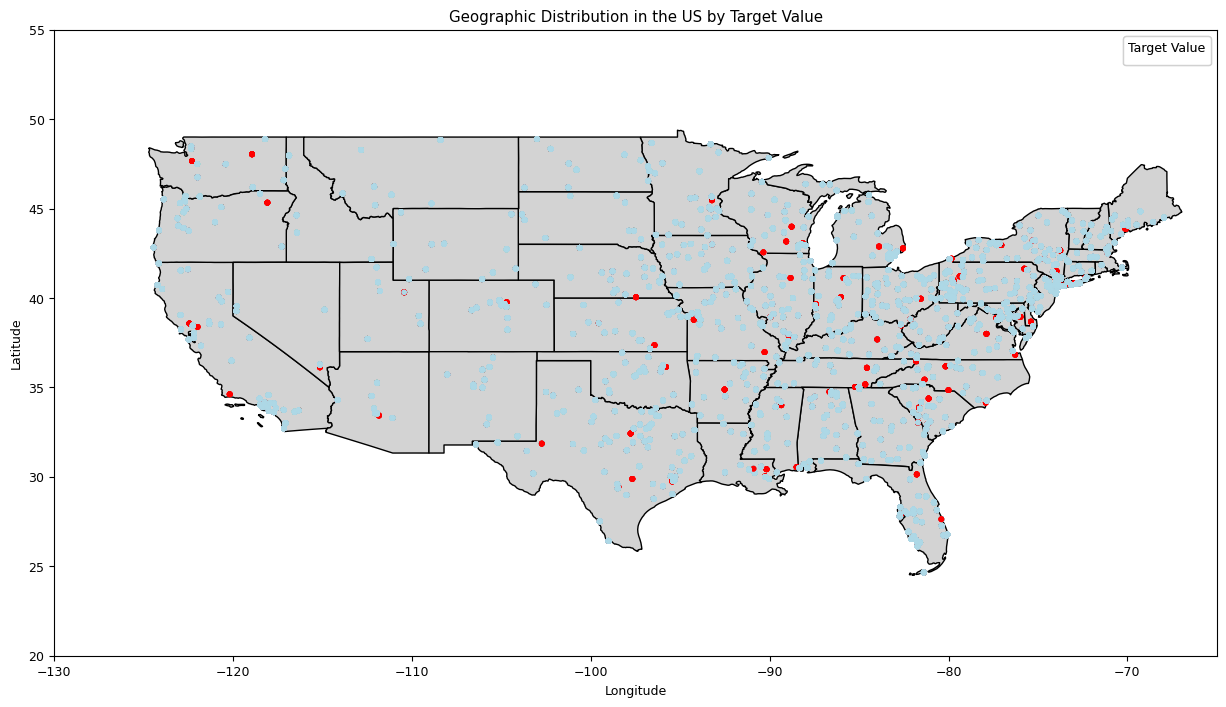

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(15, 12))

# 미국 주 경계 지도 그리기 (shapefile이 로드된 경우)
if us_states is not None:
    us_states.plot(ax=ax, color='lightgray', edgecolor='black')

# target 값에 따라 색상 지정
colors = ['lightblue' if val == 0 else 'red' for val in train['is_fraud']]
scatter_us = ax.scatter(geo_df_us.geometry.x, geo_df_us.geometry.y, c=colors, s=10)

# 범례 추가
legend_us = ax.legend(*scatter_us.legend_elements(), title="Target Value")
ax.add_artist(legend_us)

# 제목 및 축 레이블 설정
ax.set_title("Geographic Distribution in the US by Target Value")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# 미국 지도 범위에 맞게 축 제한 설정 (선택 사항)
ax.set_xlim([-130, -65])
ax.set_ylim([20, 55])

plt.show()

📌
- 쓸만한 정보는 없는 것 같긴 하지만 
    - lightblue로 칠한 부분과 꽤 겹치는 것도 있는 것으로 보아 상대적으로 인구밀도가 높은 곳에서 이루어지는 것으로 미루어 볼 수 있음

#### 거래액수 관련 피처 with target values

거래액수를 bin으로 나누어서 타깃값과의 관계를 알아봄

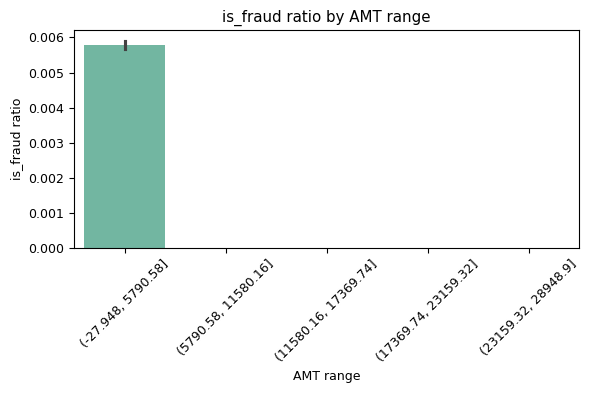

In [29]:
plt.figure(figsize=(6,4))
grid = gridspec.GridSpec(1, 1) # 하나의 서브플롯만 사용
plt.subplots_adjust(wspace=0.2, hspace=0.4) # 여백 설정 (하나의 플롯이라 큰 의미는 없음)

ax = plt.subplot(grid[0])

# 'amt' 컬럼을 지정된 개수의 구간으로 나누기
train['amt_bins'] = pd.cut(train['amt'], 5)

# 구간별 타겟 비율을 막대 그래프로 그리기
sns.barplot(x='amt_bins', y=target, data=train, palette='Set2', ax=ax)
ax.tick_params(axis='x', labelrotation=45) # x축 라벨 회전
ax.set_xlabel('AMT range')
ax.set_ylabel(f'{target} ratio')
ax.set_title(f'{target} ratio by AMT range')

plt.tight_layout() # 레이아웃 조정
plt.show()

📌
- `'amt'`에 -가 있다 : 환불의 경우 있을 수 있음
- 그리고 5로 나눈 것은 다소 무리가 있어보임
    - froud로 판정된 거래의 `'amt'` 값들을 describe 찍어보자

In [30]:
train[train['is_fraud'] == 1]['amt'].describe()

count   7,506.00
mean      531.32
std       390.56
min         1.06
25%       245.66
50%       396.50
75%       900.88
max     1,376.04
Name: amt, dtype: float64

📌
- max값이 구간별로 나뉜 첫번째 기준보다 현저히 낮음
    - 오히려 큰 금액은 사기가 아닐 가능성이 높음
    - 해당 금액으로 자른 다음 구간을 나누어 보면 어떨까

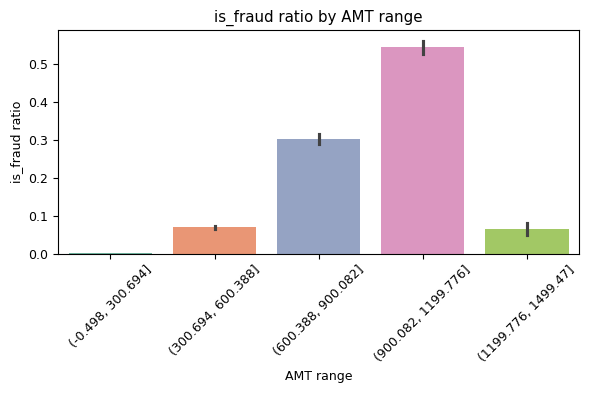

In [31]:
plt.figure(figsize=(6,4))
grid = gridspec.GridSpec(1, 1)
plt.subplots_adjust(wspace=0.2, hspace=0.4)

ax = plt.subplot(grid[0])

# `amt` <=1500 인 거래들 기준으로 5개의 구간으로 나누기
train_1500 = train[train['amt'] <= 1500]
train_1500['amt_bins'] = pd.cut(train_1500['amt'], 5)

sns.barplot(x='amt_bins', y=target, data=train_1500, palette='Set2', ax=ax)
ax.tick_params(axis='x', labelrotation=45)
ax.set_xlabel('AMT range')
ax.set_ylabel(f'{target} ratio')
ax.set_title(f'{target} ratio by AMT range')

plt.tight_layout()
plt.show()

📌
- 이 안에서도 구간별 타깃값의 비율이 다르기 때문에 `'amt'`피처는 꼭꼭 사용하는 것이 좋아보임
    - 다만 값이 구간별로 얼마나 분포해있는지 아는 것이 필요해보인다.

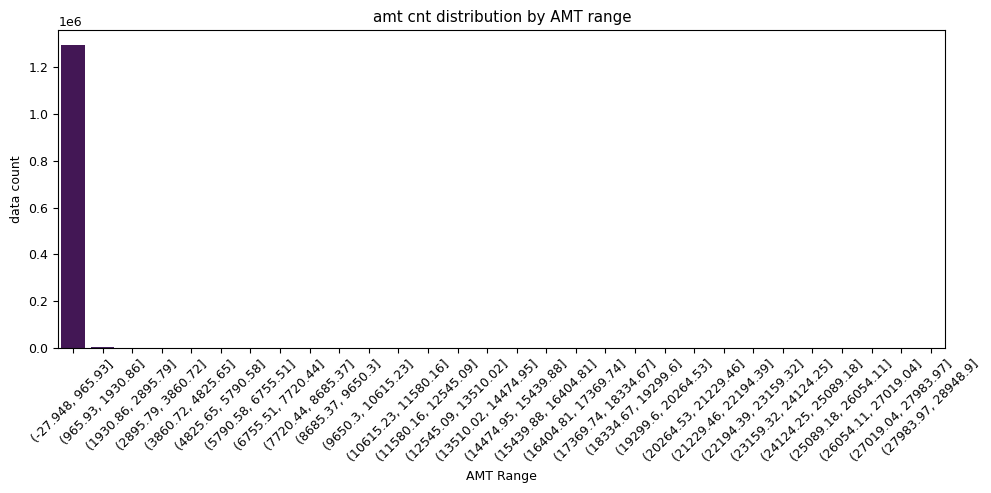

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

def plot_amt_bins_distribution(df, amt_column='amt', num_bins=5, size=(12, 6)):

    plt.figure(figsize=size)
    grid = gridspec.GridSpec(1, 1)
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    ax = plt.subplot(grid[0])

    df['amt_bins'] = pd.cut(df[amt_column], num_bins)

    bin_counts = df['amt_bins'].value_counts().sort_index()

    sns.barplot(x=bin_counts.index, y=bin_counts.values, palette='viridis', ax=ax)
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_xlabel('AMT Range')
    ax.set_ylabel('data count')
    ax.set_title(f'{amt_column} cnt distribution by AMT range')

    plt.tight_layout()
    plt.show()

plot_amt_bins_distribution(train, amt_column='amt', num_bins=30, size=(10, 5))

In [33]:
# 박스플롯 안찍기 잘했다(?)
# 1500달러 이상 거래 비율이 얼마나 될까?
print(train[train['amt'] >= 1500]['amt'].count()/train.shape[0] * 100, '% 라는뎁숑')

0.09994794377928162 % 라는뎁숑


📌
- drop하기 아까우니 amt 기준으로 2000달러 이상의 경우 처럼 상한선을 정해주는 것이 좋거나
    - 아니면 standardscaler로 처리하는 것이 좋을 것 같음


### <div style="color:rgb(4, 108, 211);"> **5. Correlation heatmap** </div>


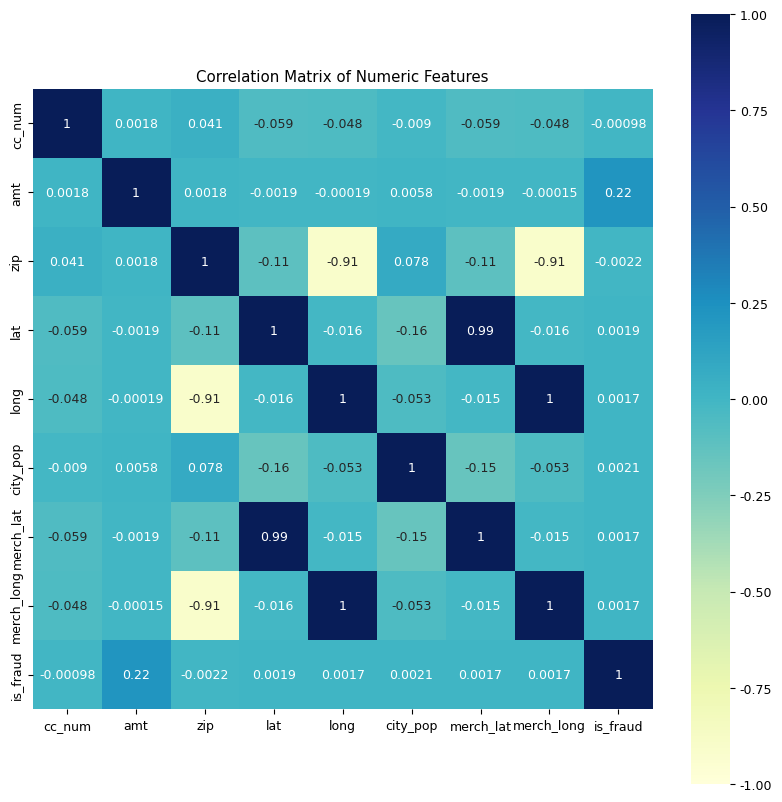

In [34]:
# Select only numeric columns
numeric_columns = train.select_dtypes(include=['float64', 'int64']).columns

plt.rcParams["figure.figsize"] = (10, 10)
plt.rcParams["font.size"] = 9
plt.rc('axes', unicode_minus=False)
sns.heatmap(train[numeric_columns].corr(), annot=True, cmap="YlGnBu", square=True, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

📌
- `'lat'`과 `'merch_lat'`, `'long'`과 `'merch_long'`이 서로 상관관계가 매우 강하게 나타나고 있음
    - 그렇지만 당장 이것이 둘 중 하나를 없애는 답이 될 수는 없음
        - 불균형이 심한 데이터로 1일때의 데이터가 중요하므로 `'is_fraud'`가 1일 때를 다시 확인해 보도록 함

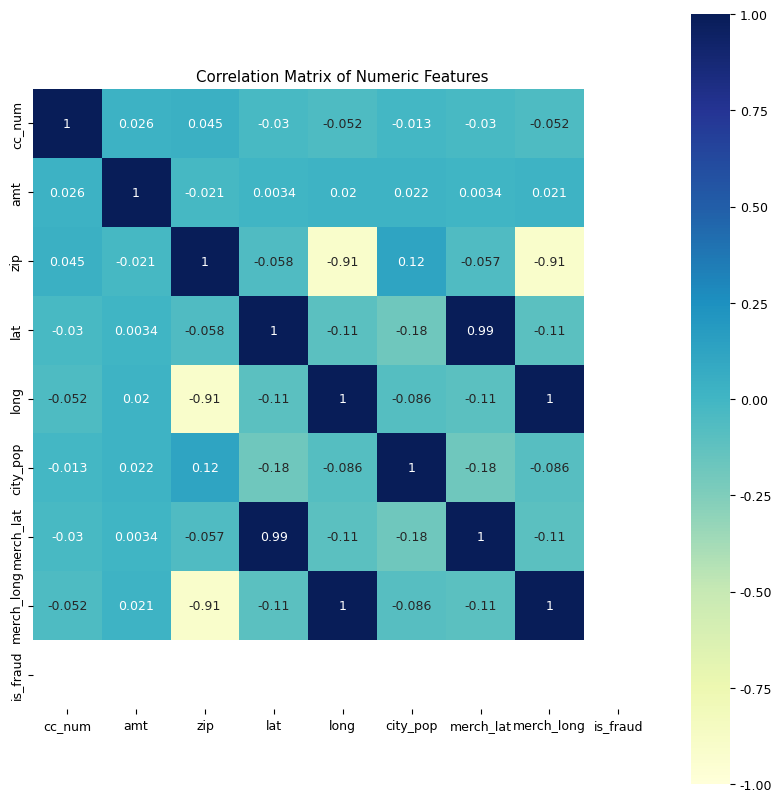

In [35]:
# Select only numeric columns
numeric_columns = train.select_dtypes(include=['float64', 'int64']).columns

plt.rcParams["figure.figsize"] = (10, 10)
plt.rcParams["font.size"] = 9
plt.rc('axes', unicode_minus=False)
sns.heatmap(train[train['is_fraud'] == 1][numeric_columns].corr(), annot=True, cmap="YlGnBu", square=True, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

📌
- 마찬가지로 비슷한 결과가 나왔음
    - 지리 정보 자체가 큰 영향을 끼치진 않을 것으로 생각
    - `'lat'`, `'long'`은 사기 피해자, `'merch_lat'`, `'merch_long'`은 사기거래 가해자로 볼 수 있기 때문에 피해자 정보만 지우는 것으로 
    - (`'is_fraud'`와 아주 근소한 차이로 lat이 merch_lat보다 높은 상관관계를 가지고 있긴 하지만)

### <div style="color:rgb(4, 108, 211);"> **6. users information** </div>

`'cc_num'`, `'first'`, `'last'`로 특정이 되는가? 

In [36]:
train['cc_num'].nunique(), test['cc_num'].nunique()

(983, 924)

In [39]:
temp = pd.concat([train['cc_num'], test['cc_num']])
temp.nunique()

999

📌
- cc_num의 경우 train 데이터에 없는 데이터도 test 데이터에에 있는 것으로 확인


이름은 ?

In [47]:
train[['first', 'last']].groupby(['first', 'last']).nunique(), test[['first', 'last']].groupby(['first', 'last']).nunique()

(Empty DataFrame
 Columns: []
 Index: [(Aaron, Murray), (Aaron, Pena), (Aaron, Rogers), (Aaron, Stewart), (Adam, Keller), (Adam, Kirk), (Adam, Mcdonald), (Adam, Riddle), (Adam, Santos), (Adam, Stark), (Adriana, Harvey), (Alan, Colon), (Alan, Howard), (Alan, Parsons), (Alan, Taylor), (Alex, Singh), (Alex, White), (Alice, Kemp), (Alicia, Bishop), (Alicia, Hawkins), (Alicia, Miller), (Alicia, Mitchell), (Alicia, Morales), (Allen, Bell), (Allison, Allen), (Allison, Ayala), (Alyssa, Morgan), (Amanda, Adams), (Amanda, Alexander), (Amanda, Fitzgerald), (Amanda, Gomez), (Amanda, Jones), (Amanda, Molina), (Amanda, Smith), (Amanda, Spencer), (Amanda, Vance), (Amanda, Wheeler), (Amanda, Williams), (Amber, Lewis), (Amber, Perez), (Amber, Thornton), (Amy, Abbott), (Amy, Daugherty), (Amy, Flynn), (Amy, Garrett), (Ana, Howell), (Ana, Mccormick), (Andrea, Cruz), (Andrea, Lewis), (Andrea, Perkins), (Andrew, Mcgee), (Andrew, Patterson), (Andrew, Tucker), (Angela, Edwards), (Angela, Hodges), (Angela, Ros

In [45]:
temp = pd.concat([train[['first', 'last']], test[['first', 'last']]])

combinations = temp.groupby(['first', 'last'])
combinations.size()


first    last    
Aaron    Murray      2920
         Pena        2191
         Rogers       741
         Stewart      737
Adam     Keller       743
                     ... 
William  Thompson    2927
Willie   Jordan      1463
Xavier   Beltran     2197
Zachary  Allen       2196
         Boone        735
Length: 989, dtype: int64

📌
- 마찬가지로 없던 이름도 있는 것으로 확인 되었음
- 사람별로 1개 이상의 카드를 소지한 것으로 추론됨
    - 특정 카드를 사용하던 패턴과 다른 방식으로 사용할 경우-라는 일반적인 사기거래 상황이 포착되기 위해서는 카드 번호도 중요하지만 사람 자체가 중요할 수 있음
    - 사람 혹은 카드에게 고유한 숫자를 부여하는 것이 좋을 수도 있겠다고 판단

## Conclusion

- `'lat'`, `'long'` 지우기
- `'amount'`는 상대적으로 중요한 정보가 될 수 있다고 판단

- `'cc_num'`은 사람과 연결되는 정보로, 사람별로 한 개 이상의 카드를 가진 것으로 추론됨